In [1]:
import numpy as np



In [10]:
from multivae.data.datasets import MultimodalBaseDataset, DatasetOutput
from numpy import ndarray
from torch import Tensor
import scipy as sp
import torch

class copula_dataset(MultimodalBaseDataset):
    
    def __init__(self):
        self.mean = np.array([3,3,3,3])

        self.cov1 = np.zeros((4,4))
        self.cov2 = np.zeros((4,4))


        for i in range(4):
            for j in range(4):
                if i==j:
                    self.cov1[i,j] = 1
                    self.cov2[i,j] = 1
                else :
                    self.cov1[i,j] = (-1)**(i+j)*0.9
                    self.cov2[i,j] = 1*0.9
        
        self.x1 = np.random.multivariate_normal(self.mean, self.cov1,size=50000)
        self.x2 = np.random.multivariate_normal(self.mean, self.cov2,size=50000)
        
        
    def __getitem__(self, index):
        
        # print(self.x1.shape)
        # print(self.x1[index])
        
        x1 = sp.stats.norm.cdf(self.x1[index], loc=3, scale=1)
        x2 = sp.stats.norm.cdf(self.x2[index], loc=3, scale=1)
        
        # print(x1, x2)
        
        # x1 = self.x1[index]
        # x2 = self.x2[index]
        
        return DatasetOutput(data = 
            {f'mod{i}' : torch.from_numpy(np.array([x1[i],x2[i]])).float() for i in range(4)}
        )


    def __len__(self):
        return len(self.x1)
    
    



In [11]:
dataset = copula_dataset()

dataset[0]


DatasetOutput([('data',
                {'mod0': tensor([0.6148, 0.7522]),
                 'mod1': tensor([0.4731, 0.8869]),
                 'mod2': tensor([0.5320, 0.6490]),
                 'mod3': tensor([0.7854, 0.6102])})])

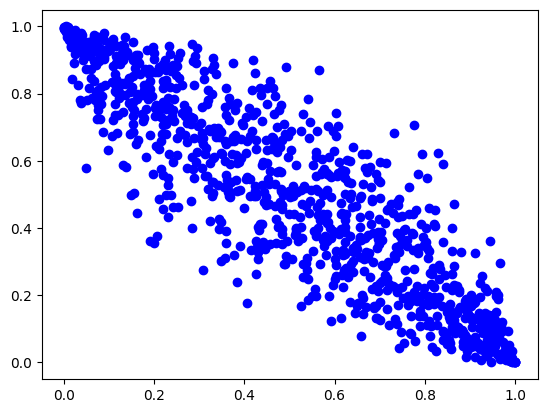

In [12]:
import matplotlib.pyplot as plt
plt.figure()
for i in range(1000):
    sample = dataset[i]
    plt.scatter(sample.data['mod0'][0],sample.data['mod1'][0], color='blue')

In [13]:
from pythae.models.nn.default_architectures import BaseEncoder, BaseDecoder, ModelOutput
from pythae.models.base import BaseAEConfig
from torch import nn

class Encoder_VAE_MLP(BaseEncoder):
    def __init__(self, args: dict):
        BaseEncoder.__init__(self)
        self.input_dim = args.input_dim
        self.latent_dim = args.latent_dim

        layers = nn.ModuleList()

        layers.append(nn.Sequential(nn.Linear(np.prod(args.input_dim), 256), nn.ReLU()))
        layers.append(nn.Sequential(nn.Linear(256, 256), nn.ReLU()))


        self.layers = layers
        self.depth = len(layers)

        self.embedding = nn.Linear(256, self.latent_dim)
        self.log_var = nn.Linear(256, self.latent_dim)

    def forward(self, x, output_layer_levels = None):
        output = ModelOutput()

        max_depth = self.depth

        if output_layer_levels is not None:

            assert all(
                self.depth >= levels > 0 or levels == -1
                for levels in output_layer_levels
            ), (
                f"Cannot output layer deeper than depth ({self.depth}). "
                f"Got ({output_layer_levels})."
            )

            if -1 in output_layer_levels:
                max_depth = self.depth
            else:
                max_depth = max(output_layer_levels)

        out = x.reshape(-1, np.prod(self.input_dim))

        for i in range(max_depth):
            out = self.layers[i](out)

            if output_layer_levels is not None:
                if i + 1 in output_layer_levels:
                    output[f"embedding_layer_{i+1}"] = out
            if i + 1 == self.depth:
                output["embedding"] = self.embedding(out)
                output["log_covariance"] = self.log_var(out)

        return output
    
    
class Decoder_AE_MLP(BaseDecoder):
    # The same as in Pythae but allows for any input shape (*, latent_dim) with * containing any number of dimensions.
    def __init__(self, args: dict):
        BaseDecoder.__init__(self)

        self.input_dim = args.input_dim

        layers = nn.ModuleList()

        layers.append(nn.Sequential(nn.Linear(args.latent_dim, 256), nn.ReLU()))
        layers.append(nn.Sequential(nn.Linear(256, 256), nn.ReLU()))


        layers.append(
            nn.Sequential(nn.Linear(256, int(np.prod(args.input_dim))), nn.Sigmoid())
        )

        self.layers = layers
        self.depth = len(layers)

    def forward(self, z: torch.Tensor):
        output = ModelOutput()

        max_depth = self.depth
        out = z

        for i in range(max_depth):
            out = self.layers[i](out)
            if i + 1 == self.depth:
                output_shape = (*z.shape[:-1],) + self.input_dim
                output["reconstruction"] = out.reshape(output_shape)

        return output


In [14]:
from multivae.models import MoPoE, MoPoEConfig

model_config = MoPoEConfig(
    n_modalities=4,
    input_dims=dict(
        mod0 = (2,),
        mod1 = (2,),
        mod2 = (2,),
        mod3 = (2,)
    ),
    latent_dim=3,
    beta=2.5,
    
)

encoders = {f'mod{i}' : Encoder_VAE_MLP(BaseAEConfig((2,),model_config.latent_dim)) for i in range(4)}
decoders = {f'mod{i}' : Decoder_AE_MLP(BaseAEConfig(input_dim=(2,), latent_dim=model_config.latent_dim)) for i in range(4)}

model = MoPoE(model_config, encoders=encoders, decoders=decoders)

print(model.encoders.keys())
model(sample)




odict_keys(['mod0', 'mod1', 'mod2', 'mod3'])


ModelOutput([('loss', tensor(8.4332, grad_fn=<AddBackward0>)),
             ('metrics',
              {'joint_divergence': tensor(0.3620, grad_fn=<MeanBackward0>),
               'recon_mod0': tensor(1.8890, grad_fn=<MeanBackward0>),
               'recon_mod1': tensor(1.8579, grad_fn=<MeanBackward0>),
               'recon_mod2': tensor(1.8888, grad_fn=<MeanBackward0>),
               'recon_mod3': tensor(1.8926, grad_fn=<MeanBackward0>)})])

In [15]:
from multivae.trainers import BaseTrainer, BaseTrainerConfig

trainer_config  = BaseTrainerConfig(
    num_epochs=200,
    
)

trainer = BaseTrainer(
    model=model,train_dataset=dataset,training_config=trainer_config
)

trainer.train()

! No eval dataset provided ! -> keeping best model on train.

Model passed sanity check !
Ready for training.

Setting the optimizer with learning rate 0.0001
Created dummy_output_dir/MoPoE_training_2024-09-13_16-49-14. 
Training config, checkpoints and final model will be saved here.

Training params:
 - max_epochs: 200
 - per_device_train_batch_size: 64
 - per_device_eval_batch_size: 64
 - checkpoint saving every: None
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Scheduler: None

Successfully launched training !

Training of epoch 1/200: 100%|██████████| 782/782 [00:34<00:00, 22.41batch/s]
--------------------------------------------------------------------------
Train loss: 8.1421
--------------------------------------------------------------------------
Training of epoch 2/200: 100%|██████████| 78

KeyboardInterrupt: 

In [8]:
embeddings = model.generate_from_prior(500)

generated_samples = model.decode(embeddings)

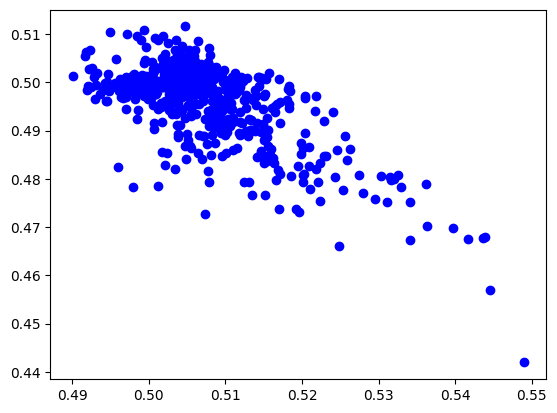

In [9]:
import matplotlib.pyplot as plt
plt.figure()
for i in range(500):
    
    plt.scatter(generated_samples['mod0'][i].detach().numpy()[0],generated_samples['mod1'][i].detach().numpy()[0], color='blue')